DistilBERT for Sentiment Analysis

In [ ]:
# install requirements
%cd D7047E-Lab1
!pip install -r requirements.txt

In [ ]:
import os
import wandb
import torch, gc
import time
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, Trainer, TrainerCallback, EarlyStoppingCallback
from transformers import DataCollatorWithPadding
from transformers import DistilBertForSequenceClassification
import evaluate
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Load local config constants
from config import NUM_LABELS, WANDB_PROJECT, SEED, SPLIT_RATIOS
from data_pipeline import load_and_split, prepare_transformer_dataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# 1. Wandb login
os.environ["WANDB_PROJECT"] = "D7047E-Lab1"
os.environ["WANDB_NAME"] = "distilbert-1gb-run"
os.environ["WANDB_DISABLED"] = "false"
wandb.login()
# 2. Reset the GPU Cache 
gc.collect()
torch.cuda.empty_cache()

In [6]:
model_name = "distilbert-base-uncased"
SUBSET_SIZE = None 
print(f"Loading Full dataset of records")
data_splits = load_and_split(subset_size=SUBSET_SIZE, seed=SEED, split_ratios=SPLIT_RATIOS)
lengths = [len(text.split()) for text in data_splits["train"]["texts"][:10000]] # Checking the first 10k rows
print(f"Average length: {np.mean(lengths):.2f}")
print(f"95th percentile: {np.percentile(lengths, 95):.2f}")
print(f"Max length in sample: {max(lengths)}")
data_splits["val"]["texts"] = data_splits["val"]["texts"][:20000]
data_splits["val"]["labels"] = data_splits["val"]["labels"][:20000]
print("Tokenizing using the shared pipeline")
tokenized_datasets = {}
for split in ["train", "val", "test"]:
    tokenized_datasets[split] = prepare_transformer_dataset(
        data_splits[split]["texts"], 
        data_splits[split]["labels"], 
        model_name, 
        max_length=128
    )
print("Creating 20K validation split")
small_val_dataset = tokenized_datasets["val"]

print("Data ready!")

Loading Full dataset of records


Average length: 74.42
95th percentile: 156.00
Max length in sample: 202
Tokenizing using the shared pipeline


Map: 100%|██████████| 360000/360000 [00:40<00:00, 8879.86 examples/s] 

Creating 20K validation split
Data ready!


In [8]:
model_name = "distilbert-base-uncased"

print("Initializing DistilBERT")
data_collator = DataCollatorWithPadding(tokenizer=AutoTokenizer.from_pretrained(model_name))
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=NUM_LABELS)

# Define Metrics
clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return clf_metrics.compute(predictions=predictions, references=labels)

class CustomLoggingCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                print(f"Step {state.global_step}: Loss {logs['loss']:.4f}")
                
# Training Arguments
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    learning_rate=4e-5,
    warmup_steps=1000,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=2,    
    per_device_eval_batch_size=64,
    dataloader_pin_memory=True,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="steps",
    eval_steps=5000,
    save_steps=5000,
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=["wandb"],               
    logging_steps=5000,
    fp16=True, 
    disable_tqdm=False,
    push_to_hub=False,
    log_level="info",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=small_val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[CustomLoggingCallback(), EarlyStoppingCallback(early_stopping_patience=5)],
)

print("Starting Training")
start_time = time.time()
trainer.train()
end_time = time.time()

print(f"Training completed in {(end_time - start_time)/60:.2f} minutes.")

Initializing DistilBERT


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6580.44it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The following columns in the Training set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids.

Starting Training


Step,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
5000,0.402045,0.159696,0.942250,0.942102,0.939794,0.944422
10000,0.309002,0.141937,0.947800,0.947155,0.954110,0.940302
15000,0.291250,0.137876,0.949950,0.949329,0.956349,0.942412
20000,0.281702,0.133746,0.951350,0.950551,0.961448,0.939899
25000,0.270204,0.129730,0.953150,0.952540,0.960176,0.945025
30000,0.262286,0.126307,0.954650,0.954388,0.955108,0.953668
35000,0.257094,0.130180,0.953650,0.953869,0.944702,0.963216
40000,0.254189,0.120903,0.957000,0.956517,0.962454,0.950653
45000,0.247971,0.117111,0.957950,0.957754,0.957417,0.958090
50000,0.199266,0.125212,0.957900,0.957659,0.958333,0.956985


The following columns in the Evaluation set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids. If token_type_ids are not expected by `DistilBertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 20000
  Batch size = 64


...

Step 65000: Loss 0.1964


Saving model checkpoint to ./distilbert_results/checkpoint-65000
Configuration saved in ./distilbert_results/checkpoint-65000/config.json
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]
Model weights saved in ./distilbert_results/checkpoint-65000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./distilbert_results/checkpoint-65000/tokenizer_config.json
The following columns in the Evaluation set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids. If token_type_ids are not expected by `DistilBertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 20000
  Batch size = 64


Step 70000: Loss 0.1941


Saving model checkpoint to ./distilbert_results/checkpoint-70000
Configuration saved in ./distilbert_results/checkpoint-70000/config.json
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]
Model weights saved in ./distilbert_results/checkpoint-70000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./distilbert_results/checkpoint-70000/tokenizer_config.json


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from ./distilbert_results/checkpoint-45000 (score: 0.11711093783378601).
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Training completed in 241.17 minutes.


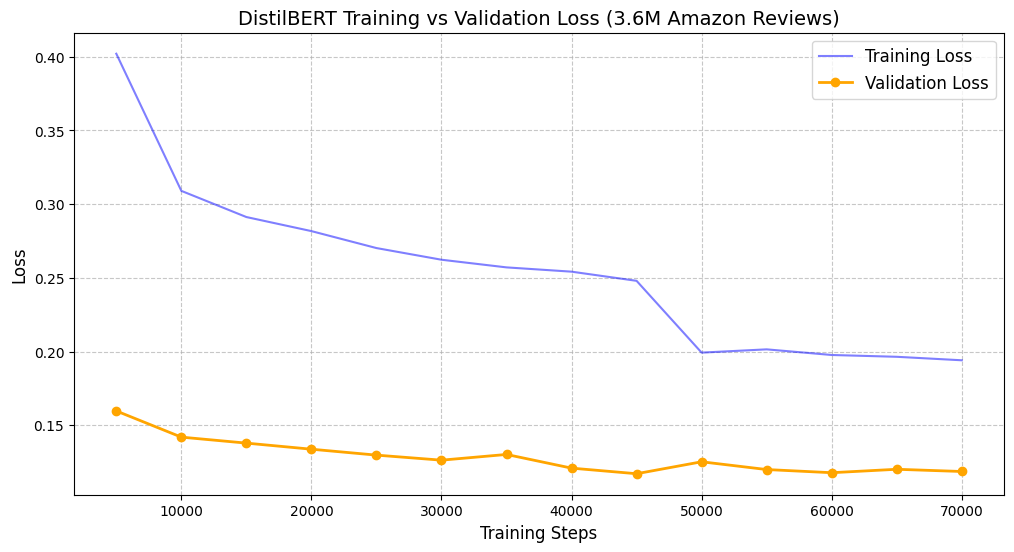

Plot saved successfully to ./results/full_dataset_loss_curve.png


In [9]:
# Extracting the logs from the trainer
log_history = trainer.state.log_history

train_steps, train_loss = [], []
eval_steps, eval_loss = [], []

# Parsing the logs
for log in log_history:
    if "loss" in log and "step" in log:
        train_loss.append(log["loss"])
        train_steps.append(log["step"])
    elif "eval_loss" in log and "step" in log:
        eval_loss.append(log["eval_loss"])
        eval_steps.append(log["step"])

# Creating the Matplotlib Plot
plt.figure(figsize=(12, 6))

# Plotting training loss
plt.plot(train_steps, train_loss, label="Training Loss", color="blue", alpha=0.5)

# Plotting validation loss (logged every 'eval_steps')
plt.plot(eval_steps, eval_loss, label="Validation Loss", color="orange", marker="o", linewidth=2)

# Formatting
plt.title("DistilBERT Training vs Validation Loss (3.6M Amazon Reviews)", fontsize=14)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Display
os.makedirs('./results', exist_ok=True)
plt.savefig('./results/full_dataset_loss_curve.png', dpi=300)
plt.show()

print("Plot saved successfully to ./results/full_dataset_loss_curve.png")

The following columns in the test set don't have a corresponding argument in `DistilBertForSequenceClassification.forward` and have been ignored: token_type_ids. If token_type_ids are not expected by `DistilBertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Prediction *****
  Num examples = 360000
  Batch size = 64


Running final test set evaluation



FINAL DISTILBERT PERFORMANCE
Test Accuracy:  0.9572
Test F1 Score:  0.9572
Test Precision: 0.9567
Test Recall:    0.9577


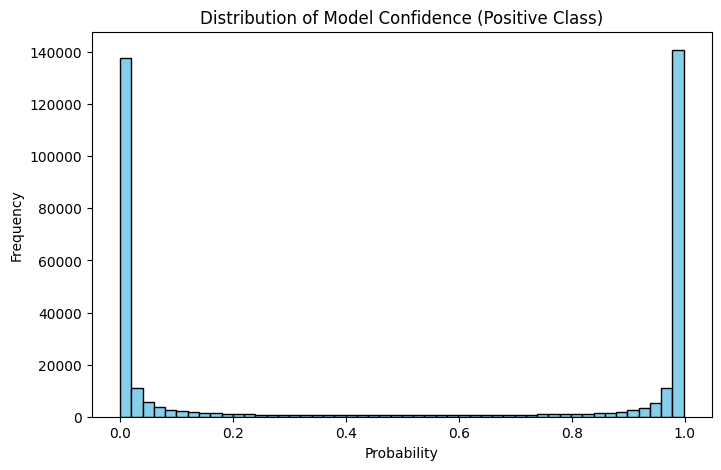

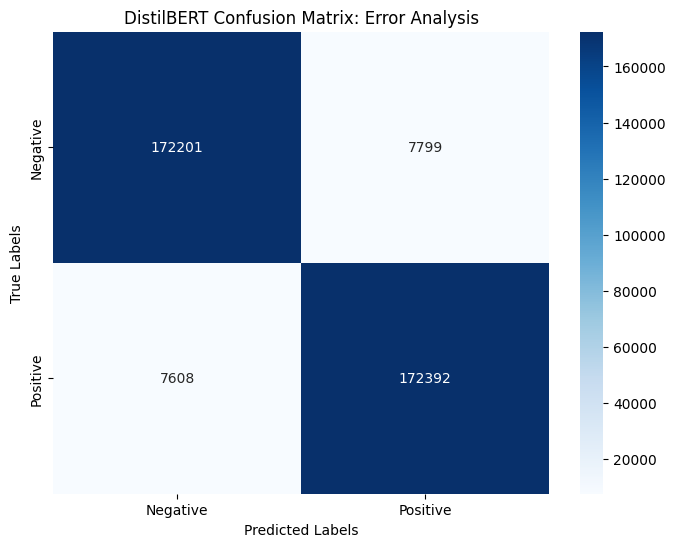


ERROR ANALYSIS SUMMARY
True Negatives (Correct): 172201
True Positives (Correct): 172392
False Positives: 7799
False Negatives: 7608

--- TOP FALSE POSITIVES (Model thought Positive, was actually Negative) ---
<ArrowStringArray>
[                                                                                                                                                                                                                                                 'I have read so many reviews on this phone before I purchased it. I got this phone for my magic jack. I needed it there because I work with my hands all day.This phone has performed wonderfully. I charge it at night and keep it on all day.The only draw back is it needs to be contoured to fit your ear. Out the box a couple of bends will suffice. The Mic is very strong... which means you need to turn it down... and the magic jack has an option to do so. I also use it on my regular line and it is awesome.UPDATE.....UPDATE....

eval/accuracy,▁▃▄▅▅▆▆▇▇▇████
eval/f1,▁▃▄▄▅▆▆▇▇▇▇███
eval/loss,█▅▄▄▃▃▃▂▁▂▁▁▁▁
eval/precision,▁▅▆▇▇▆▂█▆▆█▇▇▇
eval/recall,▂▁▂▁▃▅█▄▆▆▅▆▆▇
eval/runtime,▁▂▁▄▃▃▄▂▃▃█▃▄▄
eval/samples_per_second,█▇█▅▆▆▅▇▆▆▁▅▅▅
eval/steps_per_second,█▇█▅▆▆▅▇▆▆▁▅▅▅
test/accuracy,▁
test/f1,▁
+11,...


In [10]:
print("Running final test set evaluation")
output = trainer.predict(tokenized_datasets["test"])
test_results = output.metrics

y_preds = np.argmax(output.predictions, axis=1)
y_true = output.label_ids
# Print metrics
print("\n" + "="*40 + "\nFINAL DISTILBERT PERFORMANCE\n" + "="*40)
print(f"Test Accuracy:  {test_results['test_accuracy']:.4f}")
print(f"Test F1 Score:  {test_results['test_f1']:.4f}")
print(f"Test Precision: {test_results['test_precision']:.4f}")
print(f"Test Recall:    {test_results['test_recall']:.4f}")

# Visualization 1: Distribution of Model Confidence
probs = F.softmax(torch.from_numpy(output.predictions), dim=-1).numpy()
plt.figure(figsize=(8, 5))
plt.hist(probs[:, 1], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Model Confidence (Positive Class)")
plt.xlabel("Probability")
plt.ylabel("Frequency")
plt.show()

# Visualization 2: Confusion Matrix 
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('DistilBERT Confusion Matrix: Error Analysis')
plt.show()

# Quantitative Error Analysis
tn, fp, fn, tp = cm.ravel()
print("\n" + "="*40 + "\nERROR ANALYSIS SUMMARY\n" + "="*40)
print(f"True Negatives (Correct): {tn}")
print(f"True Positives (Correct): {tp}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print("="*40)

# Qualitative Error Analysis
error_df = pd.DataFrame({
    'text': data_splits["test"]["texts"],
    'actual': y_true,
    'predicted': y_preds,
    'confidence': [probs[i][y_preds[i]] for i in range(len(y_preds))]
})

# Filter for specific errors
false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]
false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]

# Displaying the "most confident" errors
print("\n--- TOP FALSE POSITIVES (Model thought Positive, was actually Negative) ---")
print(false_positives.sort_values(by='confidence', ascending=False).head(5)['text'].values)

print("\n--- TOP FALSE NEGATIVES (Model thought Negative, was actually Positive) ---")
print(false_negatives.sort_values(by='confidence', ascending=False).head(5)['text'].values)

# Finish session
wandb.finish()

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/config.json
Model config DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_attentions": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.5.0",
  "vocab_size": 30522
}

loading weights file model.safetensors from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/model.safetensors
Since the `dtype` attrib

Generating Heatmaps for the report


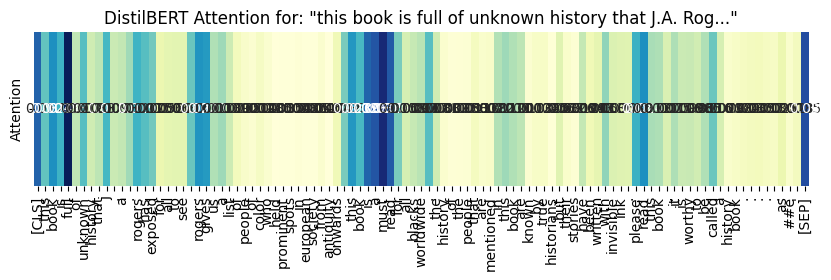

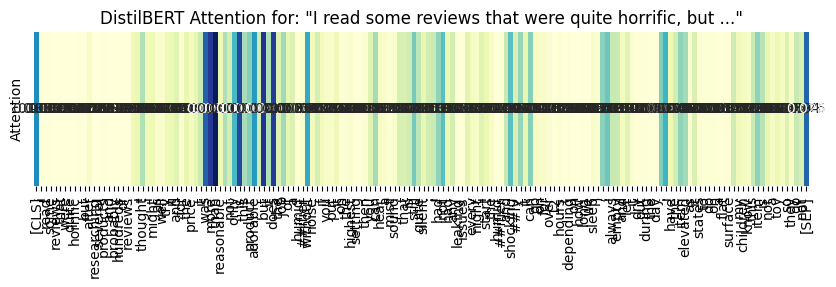

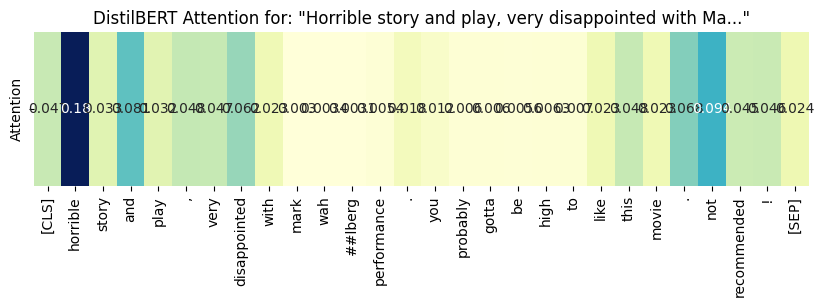

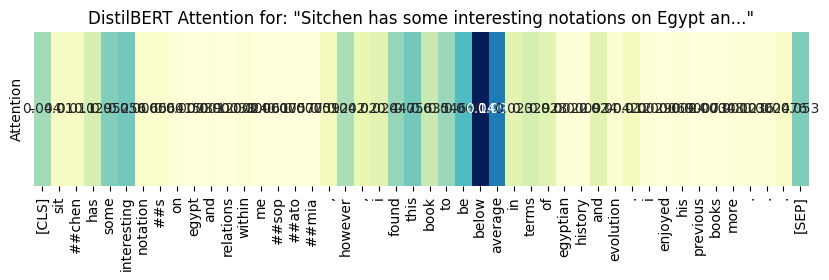

In [11]:
def visualize_attention(text, model, tokenizer):
    # 1. Preparing input
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=160).to(model.device)
    
    # 2. Getting the model outputs with attention weights
    outputs = model(**inputs, output_attentions=True)
    attention = outputs.attentions[-1] # Getting weights from the last layer
    
    # 3. Average attention across all heads
    avg_attention = attention.mean(dim=1).squeeze().detach().cpu().numpy()
    
    # 4. Tokenize for labels
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # 5. Plot Heatmap
    plt.figure(figsize=(10, 2))
    sns.heatmap(avg_attention[0:1, :len(tokens)], xticklabels=tokens, yticklabels=["Attention"], 
                annot=True, cbar=False, cmap="YlGnBu")
    plt.title(f"DistilBERT Attention for: \"{text[:50]}...\"")
    plt.show()

# Finding the first 5 examples where the model is very confident (>95%)
model_visual = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", 
    num_labels=2,
    output_attentions=True,
    attn_implementation="eager"
).to("cuda")

model_visual.load_state_dict(trainer.model.state_dict())
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
# Generate visuals for 3 positive and 3 negative
print("Generating Heatmaps for the report")

pos_indices = np.where(probs[:, 1] > 0.98)[0][:2]
neg_indices = np.where(probs[:, 0] > 0.98)[0][:2]

for idx in list(pos_indices) + list(neg_indices):
    text = data_splits["test"]["texts"][idx]
    visualize_attention(text, model_visual, tokenizer)

In [12]:
trainer.save_model("./FINAL_SUBMISSION_MODEL")

Saving model checkpoint to ./FINAL_SUBMISSION_MODEL
Configuration saved in ./FINAL_SUBMISSION_MODEL/config.json
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]
Model weights saved in ./FINAL_SUBMISSION_MODEL/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in ./FINAL_SUBMISSION_MODEL/tokenizer_config.json


Analysis and Conclusion:

Training Time: 4 hours

Final Test Accuracy: 95.7%

Convergence:

•	3.6M Dataset: Training loss decreased steadily over the course of the training run, indicating the model successfully learned from the massive data pool.

•	Peak Performance: Because the dataset size is so large (2.88 million effective training rows), the model reached its absolute minimum validation loss at approximately Step 45,000 (which mathematically corresponds to exactly 1 Epoch). The model fully converged at this point, proving that a single pass over a dataset of this scale is sufficient for DistilBERT to reach maximum intelligence.

Overfitting and Validation Strategy:
Evaluating after a full epoch (hours of training) would have been too late to catch the overfitting. Instead, we evaluated every 5,000 steps with an Early Stopping Callback (patience=5). This setup helped in catching the Epoch 2 overfitting, aborted the run, and automatically rolled us back to the optimal Step 45,000 checkpoint.

Qualitative Analysis:
When we manually reviewed the model's text predictions, we found out that many of the original "ground truth" labels in the dataset were noisy or flat-out wrong. Impressively, our best model accurately predicted the true sentiment of these reviews anyway, completely ignoring the bad labels. This proves that our model learned genuine English sentiment patterns rather than just blindly memorizing the training data.